In [ ]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/household_power_consumption.csv', sep=',',
                 parse_dates={'dt' : ['Date', 'Time']}, infer_datetime_format=True,
                 low_memory=False, na_values=['nan','?'], index_col='dt')

#  Step 1: Data Parsing and Resampling

# Resample to daily frequency (summing the active power)
daily_data = df['Global_active_power'].resample('D').sum()
daily_data = daily_data.dropna().to_frame()

/tmp/ipykernel_582/2171548379.py:4: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv('/content/drive/MyDrive/household_power_consumption.csv', sep=',',
/tmp/ipykernel_582/2171548379.py:4: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv('/content/drive/MyDrive/household_power_consumption.csv', sep=',',
/tmp/ipykernel_582/2171548379.py:4: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv('/content/drive/MyDrive/household_power_consumption.csv', sep=',',


In [ ]:
#  Step 2: Feature Engineering

def create_features(df):
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    return df

daily_data = create_features(daily_data)

In [ ]:
#  Step 3: Model Implementation and Comparison

from statsmodels.tsa.arima.model import ARIMA

# Split data (80% train, 20% test)
train_size = int(len(daily_data) * 0.8)
train, test = daily_data['Global_active_power'][:train_size], daily_data['Global_active_power'][train_size:]

# Fit ARIMA (Example parameters p=5, d=1, q=0)
arima_model = ARIMA(train, order=(5,1,0))
arima_result = arima_model.fit()
arima_forecast = arima_result.forecast(steps=len(test))

In [ ]:
# Prophet

from prophet import Prophet

# Prophet requires columns 'ds' (date) and 'y' (target)
prophet_df = daily_data.reset_index()[['dt', 'Global_active_power']].rename(columns={'dt':'ds', 'Global_active_power':'y'})
prophet_model = Prophet()
prophet_model.fit(prophet_df.iloc[:train_size])

future = prophet_model.make_future_dataframe(periods=len(test))
prophet_forecast = prophet_model.predict(future)['yhat'].iloc[train_size:]

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
# XGBoost

from xgboost import XGBRegressor

X_train = daily_data.drop('Global_active_power', axis=1).iloc[:train_size]
y_train = daily_data['Global_active_power'].iloc[:train_size]
X_test = daily_data.drop('Global_active_power', axis=1).iloc[train_size:]

xgb_model = XGBRegressor(n_estimators=1000, learning_rate=0.05)
xgb_model.fit(X_train, y_train)
xgb_forecast = xgb_model.predict(X_test)

In [ ]:
# Performance Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{label} - MAE: {mae:.2f}, RMSE: {rmse:.2f}")

evaluate(test, arima_forecast, "ARIMA")
evaluate(test, prophet_forecast, "Prophet")
evaluate(test, xgb_forecast, "XGBoost")

ARIMA - MAE: 615.62, RMSE: 743.90
Prophet - MAE: 783.28, RMSE: 917.38
XGBoost - MAE: 434.48, RMSE: 575.86


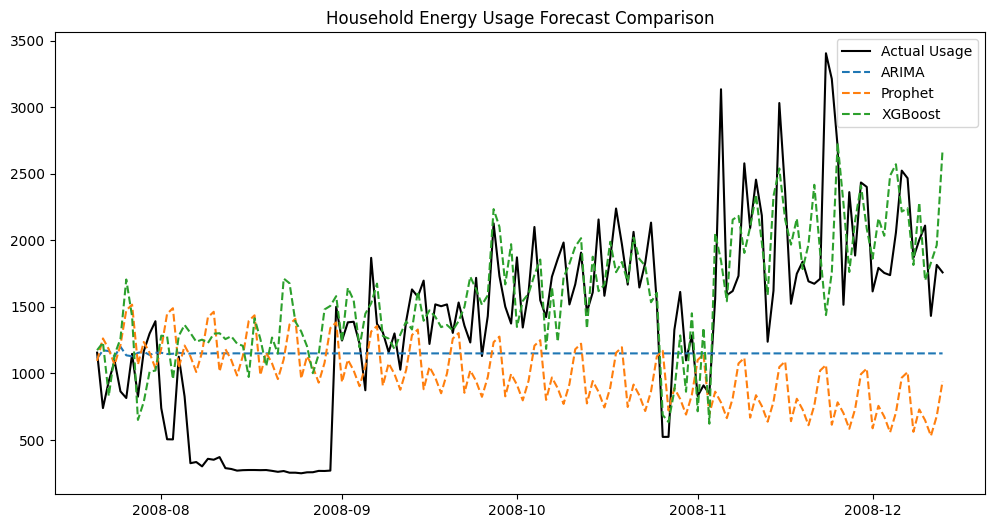

In [ ]:
# Step 5: Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(test.index, test, label='Actual Usage', color='black')
plt.plot(test.index, arima_forecast, label='ARIMA', linestyle='--')
plt.plot(test.index, prophet_forecast, label='Prophet', linestyle='--')
plt.plot(test.index, xgb_forecast, label='XGBoost', linestyle='--')
plt.title('Household Energy Usage Forecast Comparison')
plt.legend()
plt.show()